# EE519 — Speaker Verification with WavLM-ECAPA on TIMIT

**Notebook purpose.** This notebook walks through a complete text-independent speaker verification pipeline using the **TIMIT** corpus for classroom learning.

**What you will do**
- inspect the dataset and trial design
- prepare enrollment and test utterances
- extract speaker embeddings
- compute similarity scores
- evaluate system behavior using genuine vs. impostor scores and DET-style analysis

**Model focus.** WavLM-ECAPA style speaker embeddings using Hugging Face / transformer-based speaker representations.


## Notebook map

This notebook can be viewed as a four-part speaker verification pipeline:

- **Step 1 — Data engineering:** inspect the corpus, read audio, and construct enrollment/test metadata.
- **Step 2 — Representation learning:** extract speaker embeddings with a pretrained WavLM-based speaker model.
- **Step 3 — Back-end scoring:** compare enrollment and test representations using cosine similarity.
- **Step 4 — Performance analysis:** examine true/impostor score distributions and DET-style verification behavior.

Full workflow:
**speech signal → preprocessing → embedding extraction → enrollment representation → similarity scoring → verification/decision analysis**

## Know your dataset

TIMIT is a classic speech corpus widely used for speech and speaker experiments.

Key properties relevant here:
- **Clean, read speech:** useful for understanding the core mechanics of speaker verification before moving to more difficult conditions.
- **Speaker diversity:** multiple speakers make it possible to build enrollment and trial lists.
- **Phonetically rich utterances:** although this notebook focuses on speaker identity rather than phonetic recognition, phonetic diversity still affects acoustic variation.
- **Controlled recording conditions:** this often makes the signal easier to analyze and helps isolate the verification pipeline itself.

At a high level, the dataset gives you a practical sandbox for learning how a verification system is built end to end.


## Know your speaker verification task

This notebook focuses on **text-independent speaker verification**.

Core idea:
- a few utterances are used to create an **enrollment representation** for a speaker
- a new utterance is presented as a **test trial**
- the system computes a **similarity score**
- the score is interpreted as support for either **same-speaker** or **different-speaker**

Important concepts:
- **Enrollment:** reference speech used to represent a speaker.
- **Test trial:** the utterance being checked against enrolled speakers.
- **Embedding:** a compact vector representation intended to preserve speaker identity.
- **Back-end scoring:** the rule used to compare embeddings, such as cosine similarity.
- **Verification performance:** how well genuine and impostor trials are separated.

So the full problem is not just “extract embeddings,” but “design a reliable decision pipeline from audio to score.”


## Tools

Main libraries and roles in this notebook:
- **NumPy / pandas:** data handling, metadata tables, and numerical manipulation.
- **librosa / scipy / torchaudio:** waveform loading, resampling, and inspection.
- **PyTorch:** tensor operations, batching, and model inference.
- **Transformers:** access to the pretrained WavLM-based speaker representation model.
- **scikit-learn:** similarity computation and evaluation utilities.
- **matplotlib / seaborn:** visualization of score behavior and verification trends.

These tools support four connected stages:
- **Data engineering**
- **Representation learning**
- **Back-end scoring**
- **Performance analysis**


## Environment and runtime context

This notebook assumes an environment where the required audio, deep learning, and plotting libraries are available.

Useful things to keep in mind:
- a **GPU** can speed up embedding extraction, but the workflow itself is conceptually the same on CPU
- package versions can affect model loading and cached downloads
- local file paths and cache directories may need to be adapted to your machine
- saving intermediate metadata and embeddings helps avoid recomputation

The notebook is easiest to understand if you think of the environment as supporting a reproducible workflow:
**load data → run model inference → save intermediate outputs → analyze verification scores**.


# Step 1 — Data preparation and trial construction

In this stage, we prepare the TIMIT files so the later verification pipeline is clean and reproducible.

**Outputs of this stage**
- enrollment utterance list
- test utterance list
- speaker IDs associated with each file
- optional saved metadata tables for reuse


In [ ]:
import os
import librosa
import scipy.io.wavfile as wav
import numpy as np
import pandas as pd

### Read and inspect raw audio

Before jumping to embeddings, it is always useful to verify:
- sample rate
- waveform shape
- whether normalization/resampling is needed
- whether your data loader returns the format expected by the model


In [ ]:
def load_timit_wav(file_path, sr=16000):
    """
    Load a WAV file from the TIMIT dataset.
    
    Args:
        file_path (str): Path to the WAV file.
        sr (int): Target sampling rate for librosa (default: 16000).
        librosa_load (bool): If True, use librosa; else, use scipy.
    
    Returns:
        np.ndarray: Audio signal.
        int: Sampling rate.
    """
    
    audio, sr = librosa.load(file_path, sr=sr)
    audio=audio-np.mean(audio)
    audio=audio / (1.01*np.max(abs(audio)))
    # Normalize
    
    return audio, sr

### Construct enrollment and test splits

This is a key design choice in speaker verification.

Keep in mind:
- enrollment utterances should represent the target speaker
- test utterances form evaluation trials
- trial construction influences both realism and difficulty


In [ ]:
def create_enroll_test_split(dir=r"/home/mishra/My_research/TIMIT/TEST"):
    file_path_enr=[]
    spk_enr=[]
    file_path_tst=[]
    spk_tst=[]
    wav_enr=[]
    fs_enr=[]
    wav_tst=[]
    fs_tst=[]
   
    for root,_,files in os.walk(dir):
        i=0
        for file in files:
            if file.endswith(".WAV") or file.endswith(".wav"):
                file_path = os.path.join(root, file)
                spk_id = root.split(os.sep)[-1]
            
                if i<3:
                    i=i+1
                    file_path_enr.append(file_path)
                    spk_enr.append(spk_id)
                    xwav,xfs=load_timit_wav(file_path,sr=16000)
                    wav_enr.append(xwav)
                    fs_enr.append(xfs)
                else:
                    file_path_tst.append(file_path)
                    spk_tst.append(spk_id)
                    xwav,xfs=load_timit_wav(file_path,sr=16000)
                    wav_tst.append(xwav)
                    fs_tst.append(xfs)




    data_enr={
            "fname":file_path_enr,
            "spk":spk_enr,
            "wav":wav_enr,
            "fs":fs_enr

    }

    data_tst={
            "fname":file_path_tst,
            "spk":spk_tst,
            "wav":wav_tst,
            "fs":fs_tst

    }


    enr_df=pd.DataFrame(data_enr)
    tst_df=pd.DataFrame(data_tst)
    return enr_df, tst_df

### Save the metadata

Saving the enrollment and test tables helps you:
- avoid recomputing file traversal
- inspect speaker distributions
- keep the experiment reproducible across sessions


In [ ]:

enr_df,tst_df=create_enroll_test_split()


enr_df.to_pickle("enr_TIMIT.pkl")
tst_df.to_pickle("tst_TIMIT.pkl")     

In [ ]:
enr_df

In [ ]:
tst_df

### Quick sanity check with audio playback

Listening to a few utterances is a useful habit. It can reveal:
- incorrect paths
- resampling problems
- silent or corrupted files
- unexpected variability in channel or recording quality


In [ ]:
from IPython.display import Audio
Audio(enr_df.wav[5], rate=enr_df.fs[0])

### Checkpoint: what has been accomplished so far?

By now, you should have:
- created enrollment and test metadata
- verified at least one audio example
- confirmed that the file organization matches the intended experiment

This is the right time to pause and verify the assumptions before moving into model-based embedding extraction.


# Step 2 — Speaker embedding extraction with WavLM-ECAPA

Here the notebook uses a transformer-based representation pipeline for speaker verification.

Conceptually:
- the waveform is converted into features expected by the pretrained model
- the model outputs a speaker-discriminative embedding
- those embeddings are later used for enrollment averaging and similarity scoring

As you compare this notebook with the ECAPA version, ask what changes come from:
- the frontend / feature extraction
- the model architecture
- the embedding geometry


In [ ]:
import torch
import torchaudio
from transformers import WavLMForXVector, Wav2Vec2FeatureExtractor
import pandas as pd
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F

### Load the pretrained model

This section prepares access to a pretrained speaker model.

Points to think about:
- What dataset was the model pretrained on?
- How different is that dataset from TIMIT?
- Why can a pretrained model transfer reasonably well to a new verification setting?


In [ ]:
# Set environment variables for custom cache directory
os.environ["SB_DISABLE_QUIRKS"] = ""
custom_cache_dir = "D:/My_Research/HF_Cache"
os.environ["HF_HOME"] = custom_cache_dir  # Set Hugging Face cache location
#device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device="cpu" #"cuda:0"


#%% Initialize the WavLM-ECAPA-TDNN model for speaker recognition
model_name = "microsoft/wavlm-base-plus-sv"
feature_extractor = Wav2Vec2FeatureExtractor.from_pretrained(model_name)
model = WavLMForXVector.from_pretrained(model_name)

model.eval()


### Single-utterance embedding sanity check

Before running large-batch extraction, it is good practice to verify:
- the model loads correctly
- one file can be processed end-to-end
- the output embedding shape is as expected
- inference runs on the intended device


In [ ]:
import matplotlib.pyplot as plt

wav = np.array(enr_df.wav[0])
sr = enr_df.fs[0]  # sampling rate

# Create a time vector in seconds
time = np.arange(len(wav)) / sr

# Plot
plt.figure(figsize=(10, 4))
plt.plot(time, wav)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Waveform (16 kHz Sampling Rate)")
plt.grid(True)
plt.show()

Audio(enr_df.wav[0], rate=enr_df.fs[0])

In [ ]:
def load_audio(path):
    waveform, sr = torchaudio.load(path)

    if sr != 16000:
        waveform = torchaudio.functional.resample(waveform, sr, 16000)

    return waveform.squeeze()

In [ ]:
enr_df['fname']

In [ ]:
def extract_embedding_1(audio):
    inputs = feature_extractor(
        audio,
        sampling_rate=16000,
        return_tensors="pt",
        padding=True
    )

    with torch.no_grad():
        outputs = model(**inputs)
    
    embeddings = outputs.embeddings
    embeddings = torch.nn.functional.normalize(embeddings, dim=-1)

    return embeddings

In [ ]:
import torch
waveform = load_audio(enr_df['fname'][0])
emb_x = extract_embedding_1(waveform)

In [ ]:
waveform

In [ ]:
emb_x.shape

In [ ]:
emb_x

### Build the dataset and data loader

Efficient embedding extraction typically requires batching.

Design questions:
- How should variable-length utterances be handled?
- What padding strategy is being used?
- Why does batching improve throughput?


In [ ]:
TARGET_SR = 16000

class AudioDataset(Dataset):
    def __init__(self, df):
        self.df = df

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        wav = self.df.iloc[idx]["wav"]

        # Convert to tensor
        if not isinstance(wav, torch.Tensor):
            wav = torch.tensor(wav, dtype=torch.float32)

        # 🔥 FIX 1: squeeze ALL singleton dims
        wav = wav.squeeze()

        # 🔥 FIX 2: ensure it's 1D
        if wav.dim() > 1:
            wav = wav.mean(dim=0)

        # 🔥 FIX 3: convert to numpy (VERY IMPORTANT for HF)
        wav = wav.numpy()

        return wav

In [ ]:
def collate_fn(batch):
    return feature_extractor(
        batch,
        sampling_rate=16000,
        return_tensors="pt",
        padding=True
    )

In [ ]:
dataset = AudioDataset(enr_df)

dataloader = DataLoader(
    dataset,
    batch_size=32,
    shuffle=False,
    collate_fn=collate_fn,
    num_workers=2,
    pin_memory=True
)

In [ ]:
def extract_embeddings(dataloader, model, device):
    all_embeddings = []

    with torch.no_grad():
        for batch in dataloader:

            input_values = batch["input_values"].to(device)
            attention_mask = batch["attention_mask"].to(device)

            outputs = model(
                input_values=input_values,
                attention_mask=attention_mask
            )

            embeddings = outputs.embeddings  # (B, 512)

            # Normalize embeddings (VERY IMPORTANT)
            embeddings = F.normalize(embeddings, dim=-1)

            all_embeddings.append(embeddings.cpu())

    return torch.cat(all_embeddings, dim=0)

In [ ]:
embeddings = extract_embeddings(dataloader, model, device)

print(embeddings.shape)

### Stack batch outputs into a single embedding table

After batched inference, embeddings are gathered into one structure for later scoring and analysis.


In [ ]:
168*3

In [ ]:
all_embeddings = embeddings

embs_numpy = all_embeddings.detach().cpu().numpy()

# Safety check
assert len(enr_df) == len(embs_numpy)

# Assign embeddings row-wise
enr_df["embeddings"] = list(embs_numpy)

# Save
enr_df.to_pickle("enr_TIMIT_emb_wavlm.pkl")

### Persist embeddings

Saving embeddings is practical because it lets you:
- rerun scoring without repeating model inference
- compare back-end strategies
- debug performance separately from feature extraction


In [ ]:
embs_numpy=all_embeddings


enr_df['embeddings'] = [emb for emb in embs_numpy]
enr_df.to_pickle("enr_TIMIT_emb_wavlm.pkl")

In [ ]:
enr_df

### Extract embeddings for test trials

The same representation pipeline is now applied to the test utterances.

Later, these test embeddings will be compared against the enrolled speaker representations.


In [ ]:
tst_df = pd.read_pickle("tst_TIMIT.pkl")
#%%
tst_dst = AudioDataset(tst_df)


tst_dataloader = DataLoader(
    tst_dst,
    batch_size=32,
    shuffle=False,
    collate_fn=collate_fn,
    num_workers=2,
    pin_memory=True
)


tst_all_embeddings = extract_embeddings(tst_dataloader, model, device)

tst_numpy=tst_all_embeddings.detach().cpu().numpy()


tst_df['embeddings'] = list(tst_numpy)
tst_df.to_pickle("tst_TIMIT_emb_wavlm.pkl")

In [ ]:
tst_df

### First look at discriminability

Once both enrollment and test embeddings are available, we can inspect whether cosine similarity begins to separate:
- **genuine trials**: same speaker
- **impostor trials**: different speakers


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns  # for a nice heatmap
import numpy as np

# Compute cosine similarity between each row of A and each row of B
similarity_matrix = cosine_similarity(embs_numpy, tst_numpy)

# Convert to DataFrame and save
cos_sim_df = pd.DataFrame(similarity_matrix)
cos_sim_df.to_csv("cosine_similarity_matrix.csv", index=False, header=True)

# --- Visualization ---
plt.figure(figsize=(8, 6))
sns.heatmap(
    cos_sim_df,
    cmap="viridis",        # color map
    annot=False,           # set True if you want numeric values inside boxes
    cbar=True
)
plt.title("Cosine Similarity Matrix", fontsize=14)
plt.xlabel("tst_embeddings")
plt.ylabel("enrollment")
plt.tight_layout()
plt.show()


### Why cosine similarity?

In embedding-space verification, cosine similarity is often the first comparison metric to try because it directly measures how aligned two speaker vectors are.

It is simple, interpretable, and often surprisingly competitive as a baseline.


# Step 3 — Back-end scoring with cosine similarity

After embeddings are extracted, the next stage is the **verification back end**.

What happens in this part:
- enrollment utterances for each speaker are aggregated into a speaker-level representation
- each test embedding is compared with enrollment representations
- cosine similarity is used to produce verification scores

Why this matters:
- the embedding model creates the representation space
- the back end determines how comparisons are made inside that space

In other words, this stage turns learned representations into usable speaker-comparison evidence.


# Evaluation and score analysis

This section forms the verification back end:
- average enrollment embeddings per speaker
- compare against test embeddings
- compute genuine and impostor scores
- visualize score distributions
- examine operating trade-offs with DET-style curves


![Screenshot from 2025-10-09 14-39-56.png](<attachment:Screenshot from 2025-10-09 14-39-56.png>)
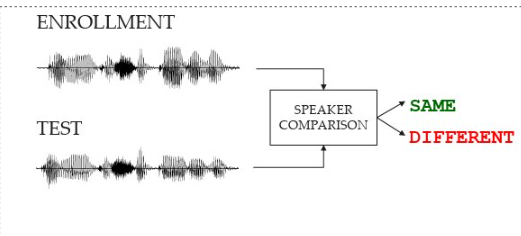

In [ ]:
enr_emb_df=pd.read_pickle("enr_TIMIT_emb_wavlm.pkl")
tst_emb_df=pd.read_pickle("tst_TIMIT_emb_wavlm.pkl")


In [ ]:
enr_emb_df

In [ ]:
tst_df

In [ ]:
Avg_enr_df=enr_emb_df.groupby("spk")["embeddings"].apply(lambda x:np.mean(np.stack(x),axis=0)).reset_index(name="avg_emb")
Avg_enr=np.vstack(Avg_enr_df["avg_emb"])

In [ ]:
Avg_enr_df

In [ ]:
Avg_enr.shape

### Continue score preparation


In [ ]:
tst_emb=np.vstack(tst_emb_df["embeddings"])

similarity_matrix = cosine_similarity(Avg_enr, tst_emb)

In [ ]:
#%% true and false score computation

enr_spk = Avg_enr_df["spk"].to_numpy()
tst_spk = tst_emb_df["spk"].to_numpy()

# Find matching speaker indices
mask = enr_spk[:, None] == tst_spk  # Shape: (num_enr, num_tst)


true_scores = similarity_matrix[mask]
false_scores = similarity_matrix[~mask]

# Step 4 — Performance analysis and verification behavior

Now the notebook moves from score generation to **performance interpretation**.

This final stage helps you examine:
- separation between genuine and impostor scores
- score-density behavior
- operating trade-offs visible through DET-style analysis

This is where the pipeline becomes measurable: not just “Did the model run?” but “How well does the system distinguish speakers?”


In [ ]:
# %% Density plots
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Set number of bins
bins = 50  

# Plot normalized histogram with KDE
plt.figure(figsize=(10, 6))
sns.histplot(true_scores, bins=bins, kde=True, stat="probability", label="True Scores", color="blue", alpha=0.5)
sns.histplot(false_scores, bins=bins, kde=True, stat="probability", label="False Scores", color="red", alpha=0.5)

# Labels and formatting
plt.xlabel("Cosine Similarity Score")
plt.ylabel("Probability Density")
plt.title("Normalized Histogram with KDE for True and False Scores")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)

plt.show()


In [ ]:
#%% compute DET curve

from sklearn.metrics import det_curve
from scipy.stats import norm

# Compute DET curve
fpr, fnr, thresholds = det_curve(
    np.concatenate([np.ones_like(true_scores), np.zeros_like(false_scores)]),
    np.concatenate([true_scores, false_scores])
)

# Convert to miss probability and false alarm probability
miss_probability = fnr  # Miss Rate (False Negative Rate)
false_alarm_probability = fpr  # False Alarm Rate (False Positive Rate)


# Apply normal deviate scale transformation (inverse normal CDF)
miss_probability_norm = norm.ppf(miss_probability)
false_alarm_probability_norm = norm.ppf(false_alarm_probability)


# Plot DET curve
plt.figure(figsize=(8, 6))
plt.plot(false_alarm_probability_norm, miss_probability_norm, label="DET Curve", linewidth=2, color='b')

# Plot EER point
eer_index = np.nanargmin(np.abs(fpr - fnr))  # Find index where FPR ≈ FNR
th=thresholds[eer_index]
eer = (fpr[eer_index] + fnr[eer_index]) / 2
eer_x = norm.ppf(fpr[eer_index])
eer_y = norm.ppf(fnr[eer_index])
plt.scatter(eer_x, eer_y, color='red', label=f"EER: {eer*100:.2f}%", zorder=3)

# Fix axis ticks to show positive values
prob_ticks = [0.001, 0.002, 0.005, 0.01, 0.02, 0.05, 0.1, 0.2, 0.5]  # Common DET scale ticks
tick_labels = [f"{p*100:.1f}%" for p in prob_ticks]

plt.xticks(norm.ppf(prob_ticks), tick_labels)
plt.yticks(norm.ppf(prob_ticks), tick_labels)

# Labels and grid
plt.xlabel("False Alarm Probability (%)")
plt.ylabel("Miss Probability (%)")
plt.title(" DET Curve")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.show()


print(f"Equal Error Rate (EER): {eer * 100:.4f}%")
print(f"Threshold: {th:.4f}")

## Reflection and brief write-up

Write a short reflection in your own words. Keep it concise but conceptually clear.

A strong response briefly connects:
- what the data preparation stage accomplished
- what the embedding model represents
- why cosine scoring is used
- what the final verification plots reveal


### Reflective questions

1. How did the notebook convert raw TIMIT waveforms into a structured enrollment/test verification task?
2. What kind of speaker information is intended to be captured by the WavLM-based speaker embeddings?
3. Why is batching important during embedding extraction?
4. What does cosine similarity measure in the context of speaker embeddings?
5. Why do genuine and impostor score distributions matter in verification?
6. What do the DET-related results tell you about operating trade-offs in the system?
7. Compared with a more conventional ECAPA-style pipeline, what might be the value of a transformer-based representation model here?


### Optional extension ideas

- compare cosine scoring with another back-end scoring approach
- test score normalization or threshold selection strategies
- inspect failure cases for acoustically similar speakers
- analyze whether utterance duration affects embedding stability
- compare performance when using fewer enrollment utterances


### One-minute summary

In this notebook, you implemented a complete **embedding-based speaker verification** workflow on TIMIT: data preparation, enrollment/test split construction, speaker embedding extraction, similarity scoring, and score-level evaluation. The main takeaway is that modern speaker verification often reduces the task to learning a representation in which **same-speaker trials score high** and **different-speaker trials score low**, after which even a simple cosine back end can provide a meaningful baseline.
